In [17]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision.datasets import ImageFolder

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    auc,
    precision_recall_curve
)
from preprocess_roi import preprocess_roi_from_uint16png

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [19]:
def preprocess_synthetic_windowed(img, size=128):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img.shape[0] != size or img.shape[1] != size:
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

    img = img.astype(np.float32)

    if img.max() > 1.5:
        img = img / 255.0

    elif img.min() < 0.0:
        img = (img + 1.0) / 2.0

    return img.astype(np.float32)

In [20]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, is_synthetic, image_size=128, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.is_synthetic = is_synthetic
        self.image_size = image_size
        self.augment = augment

        
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]
        syn_flag = self.is_synthetic[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if syn_flag:
            img = preprocess_synthetic_windowed(img, size=self.image_size)
        else:
            img = preprocess_roi_from_uint16png(img, size=self.image_size)
            
        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()
            if np.random.rand() < 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D(
                    (self.image_size//2, self.image_size//2), angle, 1.0
                )
                img = cv2.warpAffine(
                    img, M, (self.image_size, self.image_size),
                    borderMode=cv2.BORDER_REFLECT
                )
            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0, 1)

        img = img.astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0).repeat(3,1,1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)
        return img, label

In [21]:
train_dir = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\test"
syn_train_dir = r"C:\Users\rgzep\Documents\IP data\Diffusion model\synthetic_dataset"

IMG_SIZE = 128        
BATCH_SIZE = 32        
dropout_rate = 0.6
NUM_WORKERS = 0

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [22]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

real_train_paths = [s[0] for s in train_base.samples]
real_train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(real_train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['benign', 'malignant']
Train: 7758
Val: 940
Test: 853


In [23]:
minority_class_name = "benign"
minority_class_idx = class_names.index(minority_class_name)

print("Minority class index:", minority_class_idx)

Minority class index: 0


In [24]:
syn_files = os.listdir(syn_train_dir)

synthetic_train_paths = [
    os.path.join(syn_train_dir, f)
    for f in syn_files
    if f.endswith((".png"))
]

# assign ALL synthetic images to minority class
synthetic_train_labels = [minority_class_idx] * len(synthetic_train_paths)

print("Synthetic images:", len(synthetic_train_paths))

Synthetic images: 1604


In [25]:
train_paths = real_train_paths + synthetic_train_paths
train_labels = real_train_labels + synthetic_train_labels
train_is_synthetic = [False] * len(real_train_paths) + [True] * len(synthetic_train_paths)

val_is_synthetic = [False] * len(val_paths)
test_is_synthetic = [False] * len(test_paths)

print("Final train size:", len(train_paths))

Final train size: 9362


In [26]:
train_data = CTDataset(train_paths, train_labels, train_is_synthetic, image_size=IMG_SIZE, augment=False)
val_data = CTDataset(val_paths, val_labels, val_is_synthetic, image_size=IMG_SIZE, augment=False)
test_data = CTDataset(test_paths, test_labels, test_is_synthetic, image_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [27]:
model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(model.fc.in_features, num_classes)
)

model_path = "saved_models/resnet50diff_best_auc.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)
model.eval()

print("Loaded trained ResNet50")

C:\Users\rgzep\AppData\Local\Temp\ipykernel_13464\3446942191.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=de

Loaded trained ResNet50


In [28]:
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [29]:
def extract_features(dataloader, feature_extractor, device):
    all_features = []
    all_labels = []

    feature_extractor.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            features = feature_extractor(images)
            features = features.view(features.size(0), -1)

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y

In [30]:
X_train, y_train = extract_features(train_loader, feature_extractor, device)
X_val, y_val = extract_features(val_loader, feature_extractor, device)
X_test, y_test = extract_features(test_loader, feature_extractor, device)

print("Train features:", X_train.shape)
print("Val features:", X_val.shape)
print("Test features:", X_test.shape)

Train features: (9362, 2048)
Val features: (940, 2048)
Test features: (853, 2048)


In [31]:
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

print("Combined train+val features:", X_train_full.shape)

Combined train+val features: (10302, 2048)


In [32]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("svm", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

In [33]:
param_grid = {
    "pca__n_components": [100],
    "svm__kernel": ["rbf"],   
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale"]
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    scoring="recall_macro",
    cv=3,
    n_jobs=2,
    verbose=3
)

grid_search.fit(X_train_full, y_train_full)

svm_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV macro recall:", grid_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters:
{'pca__n_components': 100, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV macro recall: 0.978348272758082


In [34]:
val_pred = svm_model.predict(X_val)
val_prob = svm_model.predict_proba(X_val)[:, 1]

val_acc = accuracy_score(y_val, val_pred)
val_auc = roc_auc_score(y_val, val_prob)
val_rec = recall_score(y_val, val_pred, average="macro")

print("Validation Accuracy:", round(val_acc, 4))
print("Validation AUC:", round(val_auc, 4))
print("Validation Recall:", round(val_rec, 4))


print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

print("\nClassification Report:")
print(classification_report(
    y_val,
    val_pred,
    target_names=class_names
))

Validation Accuracy: 0.8979
Validation AUC: 0.9651
Validation Recall: 0.8952

Confusion Matrix:
[[289  37]
 [ 59 555]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.83      0.89      0.86       326
   malignant       0.94      0.90      0.92       614

    accuracy                           0.90       940
   macro avg       0.88      0.90      0.89       940
weighted avg       0.90      0.90      0.90       940



In [35]:
test_pred = svm_model.predict(X_test)
test_prob = svm_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)
test_rec = recall_score(y_test, test_pred,  average="macro")

print("Test Accuracy:", round(test_acc, 4))
print("Test AUC:", round(test_auc, 4))
print("Test Recall:", round(test_rec, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=class_names
))

Test Accuracy: 0.8007
Test AUC: 0.8711
Test Recall: 0.7953

Confusion Matrix:
[[280  92]
 [ 78 403]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.78      0.75      0.77       372
   malignant       0.81      0.84      0.83       481

    accuracy                           0.80       853
   macro avg       0.80      0.80      0.80       853
weighted avg       0.80      0.80      0.80       853



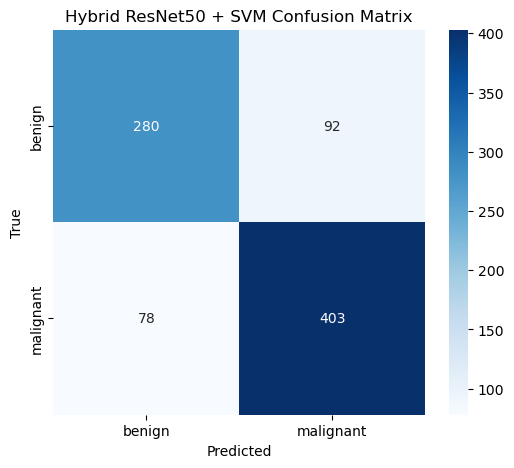

In [36]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hybrid ResNet50 + SVM Confusion Matrix")
plt.show()

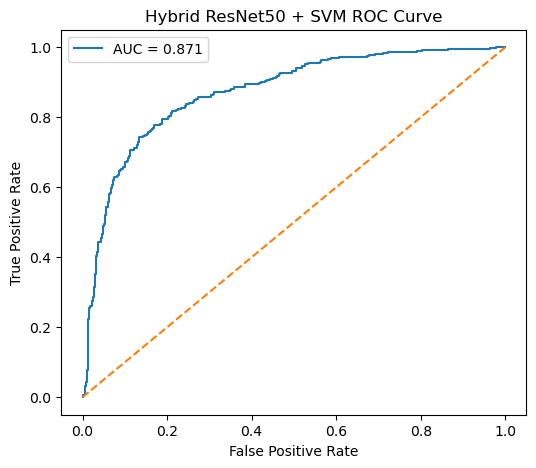

In [37]:
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Hybrid ResNet50 + SVM ROC Curve")
plt.legend()
plt.show()

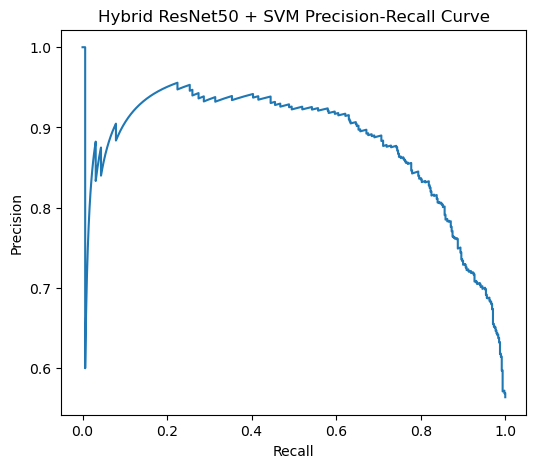

In [38]:
precision, recall, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Hybrid ResNet50 + SVM Precision-Recall Curve")
plt.show()

In [39]:
joblib.dump(
    svm_model,
    "saved_models/resnet50_svm_tuned.pkl"
)

print("Saved tuned SVM model.")

Saved tuned SVM model.
